In [51]:
"""
RetailLens — Synthetic Indian E-commerce Data Generator
Generates 4 tables: users, products, orders, events
Run: python generate_data.py
Output: CSV files in the same folder
"""

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import os



In [29]:
# steup the duck db 
! pip install duckdb

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\mm428\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [30]:
import duckdb

In [31]:
print('hello')

hello


In [32]:
# Create DuckDB Connection

In [33]:
con = duckdb.connect()

In [34]:
con.execute("""
CREATE TABLE users AS
SELECT * FROM read_csv_auto('C:/Users/mm428/users.csv')
""")

con.execute("""
CREATE TABLE products AS
SELECT * FROM read_csv_auto('C:/Users/mm428/products.csv')
""")

con.execute("""
CREATE TABLE orders AS
SELECT * FROM read_csv_auto('C:/Users/mm428/orders.csv')
""")

con.execute("""
CREATE TABLE events AS
SELECT * FROM read_csv_auto('C:/Users/mm428/events.csv')
""")

In [35]:
con.execute("SHOW TABLES").fetchdf()

,name
0,events
1,orders
2,products
3,users


# Financial Analysis: Monthly Performance & Growth

## Goal of this Query
This query answers the core question: **“For each month, how much revenue did we make, how many orders happened, how many unique customers bought, what was the average order value, and what was the month-over-month growth?”**

---

## Key Metrics Calculated

The query computes the following performance indicators on a monthly cadence:

*   **GMV (Gross Merchandise Value):** Total revenue generated.
*   **Order Count:** Total number of orders placed.
*   **Unique Buyers:** Count of distinct customers who made a purchase.
*   **AOV (Average Order Value):** The average amount spent per order, calculated as:
    $$\text{AOV} = \frac{\text{Total Revenue}}{\text{Total Orders}}$$
*   **MoM Growth %:** The percentage change in revenue compared to the previous month, calculated as:
    $$\text{MoM Growth \%} = \frac{\text{Current Month Revenue} - \text{Previous Month Revenue}}{\text{Previous Month Revenue}} \times 100$$

In [36]:
print('What happened in the business every month and whether the company is growing or declining')
query_1="""SELECT
    order_month,
    COUNT(order_id) AS total_orders,
    COUNT(DISTINCT user_id) AS unique_buyers,
    ROUND(SUM(order_value_inr), 0) AS total_revenue,
    ROUND(AVG(order_value_inr), 0) AS avg_order_value ,
    ROUND(
        (SUM(order_value_inr)
        - LAG(SUM(order_value_inr))
        OVER (ORDER BY order_month)) * 100.0 /
        NULLIF(
            LAG(SUM(order_value_inr))
            OVER (ORDER BY order_month), 0
        ), 1
    ) AS mom_growth_pct
FROM orders
WHERE status = 'Delivered'
GROUP BY order_month
ORDER BY order_month;
"""

con.execute(query_1).fetchdf()

What happened in the business every month and whether the company is growing or declining


,order_month,total_orders,unique_buyers,total_revenue,avg_order_value,mom_growth_pct
0,2024-01,1355,1077,23315650.0,17207.0,NaN
1,2024-02,1218,983,19423110.0,15947.0,-16.7
2,2024-03,1391,1069,22549600.0,16211.0,16.1
3,2024-04,1339,1041,20934490.0,15634.0,-7.2
4,2024-05,1388,1088,24854290.0,17907.0,18.7
5,2024-06,1236,1002,19336130.0,15644.0,-22.2
6,2024-07,1337,1051,20486610.0,15323.0,5.9
7,2024-08,1442,1120,21994240.0,15253.0,7.4
8,2024-09,1328,1057,19320010.0,14548.0,-12.2
9,2024-10,1402,1081,20275490.0,14462.0,4.9


In [37]:
# # explination 
# avg_order_value = each oredr value in this month eample jan 2024 total
# orders is 1355 in this 1355 each order avg amount is 17207 

# Strategic Analysis: Regional Performance & Market Share

## Goal of This Query
This query answers the critical question: **“Which cities generate the most revenue for the business?”** 

It helps the business understand:
*   Which city drives the highest sales volume?
*   Which city processes the most orders?
*   Where customers have the highest purchasing power (spend more money)?
*   Which city contributes the most to total business revenue?

---

## 💼 The Business Problem
Imagine you own a national e-commerce company selling across major hubs like **Bengaluru, Mumbai, Delhi, and Hyderabad**. To optimize marketing spend, logistics, and inventory, you need to know exactly **“Where is our business strongest?”** 

This query provides the data-driven answer to that question.

---

## What This Query Calculates
For each individual city, the query extracts and computes:
1.  **Total Orders:** Transaction volume.
2.  **Total Revenue:** Gross sales amount in INR.
3.  **Average Order Value (AOV):** How much a customer spends per order on average ($\text{AOV} = \frac{\text{Total Revenue}}{\text{Total Orders}}$).
4.  **Revenue Contribution %:** The city's share of total company revenue, calculated as:
    $$\text{Revenue Share \%} = \frac{\text{City Revenue}}{\text{Total Company Revenue}} \times 100$$



In [38]:
query_2 = """
SELECT
    u.city,
    COUNT(o.order_id) AS orders,
    ROUND(SUM(o.order_value_inr), 0) AS revenue_inr,
    ROUND(AVG(o.order_value_inr), 0) AS aov_inr,
    ROUND(
        SUM(o.order_value_inr) * 100.0 /
        SUM(SUM(o.order_value_inr)) OVER (),
        1
    ) AS revenue_share_pct
FROM orders o
JOIN users u
    ON o.user_id = u.user_id
WHERE o.status = 'Delivered'
GROUP BY u.city
ORDER BY revenue_inr DESC;
"""

result = con.execute(query_2).fetchdf()

result

,city,orders,revenue_inr,aov_inr,revenue_share_pct
0,Bengaluru,3677,58304830.0,15857.0,23.1
1,Delhi,3112,51349280.0,16500.0,20.4
2,Mumbai,3250,46876260.0,14423.0,18.6
3,Hyderabad,1740,28459100.0,16356.0,11.3
4,Chennai,1525,23892770.0,15667.0,9.5
5,Kolkata,1092,17528780.0,16052.0,6.9
6,Pune,1054,16241950.0,15410.0,6.4
7,Ahmedabad,558,9656370.0,17305.0,3.8


## 📊 Business Insights & Executive Summary

Based on the query results, we can draw the following strategic conclusions about our regional performance:

*   **🏆 Market Leader:** **Bengaluru** stands out as our strongest market, driving both the highest total revenue and the maximum volume of orders.
*   **⚖️ Revenue Concentration:** The **top 3 cities contribute 62.1% of total revenue**. This indicates a high concentration of business in a few key hubs, highlighting a potential dependency risk.
*   **💎 High-Value/Low-Scale Market:** **Ahmedabad** boasts the highest Average Order Value (AOV). While customers here spend heavily per transaction, the overall order volume is low, indicating a niche but high-value customer base.
*   **📦 High-Volume/Low-Spend Market:** **Mumbai** generates a large volume of orders but maintains a lower AOV, suggesting that customers here tend to buy lower-priced items or make cheaper, more frequent purchases.
*   **🚀 Growth Opportunities:** **Pune and Ahmedabad** represent markets with low scale. They require targeted expansion and marketing strategies to grow their customer base and scale up total order volumes. at the top of the table.

# Product Category Revenue & Performance Analysis

## 🎯 Goal of This Query
This query directly answers the critical strategic question: **“Which product categories drive our business revenue?”**

It provides deep insights into category-level dynamics to help the business understand:
* **Sales Volume:** Which category sells the most individual units?
* **Revenue Generation:** Which category brings in the highest total monetary value?
* **Customer Spending Behavior:** Which product categories do customers spend the most money on per transaction?
* **Portfolio Distribution:** Which category contributes the most to the total business ecosystem?

---

## 💼 The Business Problem
Imagine you run a scaling e-commerce company across multiple diverse lines of business, including:
* 💻 Electronics
* 👗 Clothing
* 🧴 FMCG
* 📚 Books
* 🍳 Home & Kitchen

During a strategic review, the CEO asks a fundamental question: **“Which product category is actually making us money, and where should we allocate capital next quarter?”** This query cuts through the noise to provide an immediate, data-driven answer.

---

## 📊 What This Query Calculates
For each individual product category, the query extracts, aggregates, and computes the following metrics:

1.  **Number of Orders:** The unique transaction count per category to measure purchase frequency.
2.  **Units Sold:** The total volume of items sold, identifying physical inventory movement.
3.  **Revenue Generated:** The gross sales amount (GMV) produced by the category.
4.  **Average Order Value (AOV):** The mean spend amount when a customer buys from this category, calculated as:
    $$\text{AOV} = \frac{\text{Total Category Revenue}}{\text{Total Category Orders}}$$
5.  **Revenue Contribution %:** The category's explicit share of total company-wide revenue, calculated via a window function:
    $$\text{Revenue Share \%} = \frac{\text{Category Revenue}}{\text{Total Company Revenue}} \times 100$$

In [39]:
query_3 = """
SELECT
    p.category,
    COUNT(o.order_id) AS orders,
    SUM(o.quantity) AS units_sold,
    ROUND(SUM(o.order_value_inr), 0) AS revenue_inr,
    ROUND(AVG(o.order_value_inr), 0) AS aov_inr,
    ROUND(
        SUM(o.order_value_inr) * 100.0 /
        SUM(SUM(o.order_value_inr)) OVER (),
        1
    ) AS revenue_share_pct
FROM orders o
JOIN products p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category
ORDER BY revenue_inr DESC;
"""

result = con.execute(query_3).fetchdf()

result

,category,orders,units_sold,revenue_inr,aov_inr,revenue_share_pct
0,Electronics,3211,4662.0,209344970.0,65196.0,83.0
1,Clothing,4713,6916.0,17742690.0,3765.0,7.0
2,Home & Kitchen,1582,2241.0,17192540.0,10868.0,6.8
3,FMCG,4027,5952.0,4451350.0,1105.0,1.8
4,Books,2475,3527.0,3577790.0,1446.0,1.4


## 📈 Executive Case Study Summary

* **Electronics Dominance:** Electronics is our primary growth engine, contributing a massive **83% of total revenue** driven by a premium Average Order Value (AOV) of ₹65K, despite lower order volumes.
* **Volume vs. Value:** Clothing drives the **highest overall order volume** but yields low total revenue due to a small AOV (₹3,765), highlighting an immediate opportunity for premium upselling or product bundling.
* **High-Margin Potential:** Home & Kitchen matches Clothing’s revenue with **70% fewer orders** due to a strong AOV (₹10,868), marking it as a high-potential category for targeted scaling.
* **Low-Value Scale:** FMCG and Books experience steady transactional demand but contribute negligible revenue to the business ecosystem because of very low average basket sizes.
* **Concentration Risk:** The ultimate strategic takeaway is a severe **revenue concentration risk**, leaving the company dangerously over-dependent on a single category (Electronics) for its financial stability.

# 📉 Post-Purchase Analysis: Cancellation & Return Performance

## 🎯 Main Goal of This Query
This query directly answers the critical operational question: **“Which product categories have the highest cancellation and return problems?”**

It serves as a business quality and performance health-check to identify:
*   **Customer Friction:** Which categories face the highest pre-delivery cancellations?
*   **Product Satisfaction:** Which categories suffer from excessive post-delivery returns?
*   **Operational Flags:** Are there hidden quality control, sizing, or logistics issues?
*   **Bottom-Line Impact:** Which product lines are actively hurting business profitability?

---

## 💼 Why the Business Cares: Revenue vs. Leaking Cash
While a standard sales query shows **where the business is making money**, this query focuses entirely on **where the business is losing money**. 

These two issues impact our operations differently:

*   **Cancelled Orders (Pre-Delivery Loss):** The customer cancels before the product is successfully shipped or received. 
    *   *Impact:* Lost sales opportunity and wasted digital acquisition efforts.
*   **Returned Orders (Post-Delivery Financial Drain):** The customer receives the product but sends it back due to sizing errors, defects, or unmet expectations.
    *   *Impact:* The business loses the **initial delivery cost**, **packaging costs**, **forward/reverse logistics expenses**, **net revenue**, and crucially, **customer trust**.

---

## 📊 Metrics Computed
For each individual product category, this query extracts and calculates:

1.  **Total Orders:** The baseline volume of all placed orders.
2.  **Cancelled Orders:** The total count of orders with a `Cancelled` status.
3.  **Returned Orders:** The total count of orders with a `Returned` status.
4.  **Cancellation %:** The proportion of orders cancelled before completion:
    $$\text{Cancellation \%} = \frac{\text{Cancelled Orders}}{\text{Total Orders}} \times 100$$
5.  **Return %:** The proportion of completed orders that resulted in a return:
    $$\text{Return \%} = \frac{\text{Returned Orders}}{\text{Total Orders}} \times 100$$

In [40]:
query_4 = """
SELECT
    p.category,
    COUNT(o.order_id) AS total_orders,
    
    SUM(
        CASE
            WHEN o.status = 'Cancelled'
            THEN 1
            ELSE 0
        END
    ) AS cancelled,

    SUM(
        CASE
            WHEN o.status = 'Returned'
            THEN 1
            ELSE 0
        END
    ) AS returned,

    ROUND(
        SUM(
            CASE
                WHEN o.status = 'Cancelled'
                THEN 1
                ELSE 0
            END
        ) * 100.0 /
        COUNT(o.order_id),
        1
    ) AS cancel_rate_pct,

    ROUND(
        SUM(
            CASE
                WHEN o.status = 'Returned'
                THEN 1
                ELSE 0
            END
        ) * 100.0 /
        COUNT(o.order_id),
        1
    ) AS return_rate_pct

FROM orders o
JOIN products p
    ON o.product_id = p.product_id

GROUP BY p.category

ORDER BY cancel_rate_pct DESC;
"""

result = con.execute(query_4).fetchdf()

result

,category,total_orders,cancelled,returned,cancel_rate_pct,return_rate_pct
0,Electronics,4009,499.0,299.0,12.4,7.5
1,Clothing,5908,728.0,467.0,12.3,7.9
2,FMCG,5022,588.0,407.0,11.7,8.1
3,Books,3075,356.0,244.0,11.6,7.9
4,Home & Kitchen,1986,226.0,178.0,11.4,9.0


## 📉 Executive Operational Summary

* **Critical Revenue Risk:** Electronics suffers from the highest cancellation rate (**12.4%**), creating massive revenue leakage in our most vital financial category.
* **Sizing & Fulfillment Bottlenecks:** Clothing generates the highest overall order volume but is plagued by high cancellations and returns (**12.3% and 7.9%**), signaling deep friction with sizing and product visualization.
* **Quality & Satisfaction Flags:** Home & Kitchen holds the highest return rate (**9.0%**), alerting management to urgent product expectation mismatches or transit damage issues.
* **Perishable Logistics Strain:** FMCG maintains high order frequency but exhibits an elevated **8.1% return rate**, likely pointing to delivery delays, damages, or expiry concerns.
* **Systemic Operations Breakdown:** Because cancellations (**11–12%**) and returns (**7–9%**) are consistently high across *all* business lines, the root cause is a platform-wide supply chain or logistical issue rather than single-category failures.

# 💳 Payment Method Revenue & Performance Analysis

## 🎯 Main Goal of This Query
This query directly answers the strategic financial question: **“Which payment methods generate the most business revenue?”**

It provides key transaction data to help the business understand:
*   **Customer Preferences:** Which payment gateway or method do customers select most frequently?
*   **Revenue Generation:** Which payment mode funnels the highest total monetary volume into the business?
*   **Spending Capacity:** Where do customers exhibit higher purchasing power (higher average ticket size)?
*   **Marketing Focus:** Which payment options should the business actively incentivize or promote?

---

## 💼 The Business Problem
Imagine your marketing and product teams are debating resource allocation. The management asks a practical, bottom-line question: 

> **“Should we spend our budget pushing UPI cashback offers, or should we partner with banks for Credit Card discount campaigns?”**

By breaking down the revenue and order traits of options like **UPI, Credit Cards, Debit Cards, Wallets, and COD (Cash on Delivery)**, this query provides the data-backed answer to maximize marketing ROI.

---

## 📊 What This Query Calculates
For each individual payment method, the query aggregates and computes:

1.  **Total Orders:** The aggregate count of completed transactions to determine usage frequency and popularity.
2.  **Total Revenue:** The gross sales volume driven by that specific payment gateway.
3.  **Average Order Value (AOV):** The average amount spent per transaction using that specific method, calculated as:
    $$\text{AOV} = \frac{\text{Total Revenue by Payment Method}}{\text{Total Orders by Payment Method}}$$

In [41]:
query_5 = """
SELECT
    payment_method,
    COUNT(order_id) AS orders,
    ROUND(SUM(order_value_inr), 0) AS revenue_inr,
    ROUND(AVG(order_value_inr), 0) AS aov_inr
FROM orders
WHERE status = 'Delivered'
GROUP BY payment_method
ORDER BY revenue_inr DESC;
"""

result = con.execute(query_5).fetchdf()

result

,payment_method,orders,revenue_inr,aov_inr
0,UPI,6821,110243000.0,16162.0
1,Credit_Card,3564,53822730.0,15102.0
2,Debit_Card,2520,39937970.0,15848.0
3,COD,1869,29234080.0,15642.0
4,Wallet,1234,19071560.0,15455.0


## 📊 Executive Payment Analytics Summary

* **👑 Unrivaled Market Leader:** **UPI** completely dominates the platform, capturing the highest order volume (**6,821 orders**) and driving **₹110.2M in revenue** due to its seamless checkout experience and mobile accessibility.
* **💳 Premium Financing Opportunities:** While **Credit Cards** handle fewer transactions than UPI, they generate a massive **₹53.8M in revenue**, pointing to a reliable high-value user base ideal for EMI partnerships and premium bank discounts.
* **📦 The Persistence of COD:** **Cash on Delivery (COD)** remains a critical revenue channel (**₹29.2M**). However, it represents an operational risk area that requires close monitoring due to its historical correlation with higher delivery cancellation rates.
* **📱 Wallet Stagnation:** **Wallets** rank as the least preferred payment gateway, capturing only **₹19.1M in revenue**, signaling limited customer adoption and minimal need for further marketing investment.
* **💡 Uniform Spending Behavior:** The most critical strategic discovery is that **Average Order Value (AOV) is nearly identical (~₹15K–₹16K) across all payment methods**. This proves that payment choice does not dictate consumer spending capacity; instead, total revenue is strictly driven by transaction volume.



# 👥 Customer Segmentation: Premium vs. Non-Premium User Value

## 🎯 Main Goal of This Query
This query directly answers the fundamental customer segmentation question: **“Do premium users generate more business value than non-premium users?”**

It serves as a deep dive into user value to help the business compare:
*   **Premium Users (`True`):** Customers enrolled in our subscription/loyalty tier.
*   **Non-Premium Users (`False`):** Standard marketplace customers.

---

## 💼 The Business Problem
Imagine the executive leadership is evaluating the financial impact of your loyalty program. The CEO asks:

> **“Are premium customers actually worth the operational cost of keeping them, or should we stop investing in the premium membership program altogether?”**

By contrasting the purchasing habits of both groups, this query delivers clear, data-backed evidence to justify keeping, expanding, or altering the premium tier.

---

## 📊 What This Query Calculates
For both Premium and Non-Premium segments, the query extracts and computes the following core metrics:

1.  **Total Users:** The size of the active customer base in each segment.
2.  **Total Orders:** The aggregate purchase volume to measure transaction frequency.
3.  **Revenue Generated (GMV):** The total monetary value brought in by each group.
4.  **Average Order Value (AOV):** The average amount spent per transaction, calculated as:
    $$\text{AOV} = \frac{\text{Total Segment Revenue}}{\text{Total Segment Orders}}$$
5.  **Revenue per User (ARPU):** The lifetime financial value of an individual user within that segment, calculated as:
    $$\text{Revenue per User} = \frac{\text{Total Segment Revenue}}{\text{Total Segment Users}}$$

In [42]:
query_6 = """
SELECT
    u.is_premium,
    COUNT(DISTINCT u.user_id) AS users,
    COUNT(o.order_id) AS orders,
    ROUND(SUM(o.order_value_inr), 0) AS total_revenue_inr,
    ROUND(AVG(o.order_value_inr), 0) AS aov_inr,
    ROUND(
        SUM(o.order_value_inr) /
        NULLIF(COUNT(DISTINCT u.user_id), 0),
        0
    ) AS revenue_per_user_inr
FROM users u
LEFT JOIN orders o
    ON u.user_id = o.user_id
    AND o.status = 'Delivered'
GROUP BY u.is_premium;
"""

result = con.execute(query_6).fetchdf()

result

,is_premium,users,orders,total_revenue_inr,aov_inr,revenue_per_user_inr
0,True,871,2776,44416330.0,16000.0,50995.0
1,False,4129,13232,207893010.0,15711.0,50349.0


## 📊 Executive Segmentation & Strategy Summary

*   **🛒 Core Revenue Engine:** **Non-Premium users completely drive the business**, contributing the overwhelming majority of total users, orders, and revenue simply due to the sheer size of the customer base.
*   **⚖️ Marginal Spend Variance:** **Average Order Value (AOV)** is almost identical between the two tiers. Premium users spend only **₹289 more per order** than non-premium users, proving that the premium badge is not currently driving higher transactional value.
*   **💰 Stagnant Customer Lifetime Value:** **Revenue per User** shows a negligible gap of **only ₹646**. This indicates that over time, a premium member does not generate significantly more total value than a standard user.
*   **🔄 Identical Purchase Frequency:** Both segments average exactly **~3.2 orders per user**. This reveals a critical hidden truth: the premium tier is completely failing to incentivize repeat purchase behavior or build brand loyalty.
*   **🚨 Program Performance Alert:** The core expectation of a loyalty model (higher spend, higher order frequency, and outsized user value) is completely missing. This strongly suggests that the **current premium membership program offers weak, unappealing benefits** and fails to deliver tangible business value.



In [43]:


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Re-run all queries into named dataframes
df_monthly  = con.execute(query_1).fetchdf()
df_city     = con.execute(query_2).fetchdf()
df_category = con.execute(query_3).fetchdf()
df_returns  = con.execute(query_4).fetchdf()
df_payment  = con.execute(query_5).fetchdf()
df_premium  = con.execute(query_6).fetchdf()

sns.set_theme(style="whitegrid", palette="muted")
print("✓ Ready to plot")

✓ Ready to plot


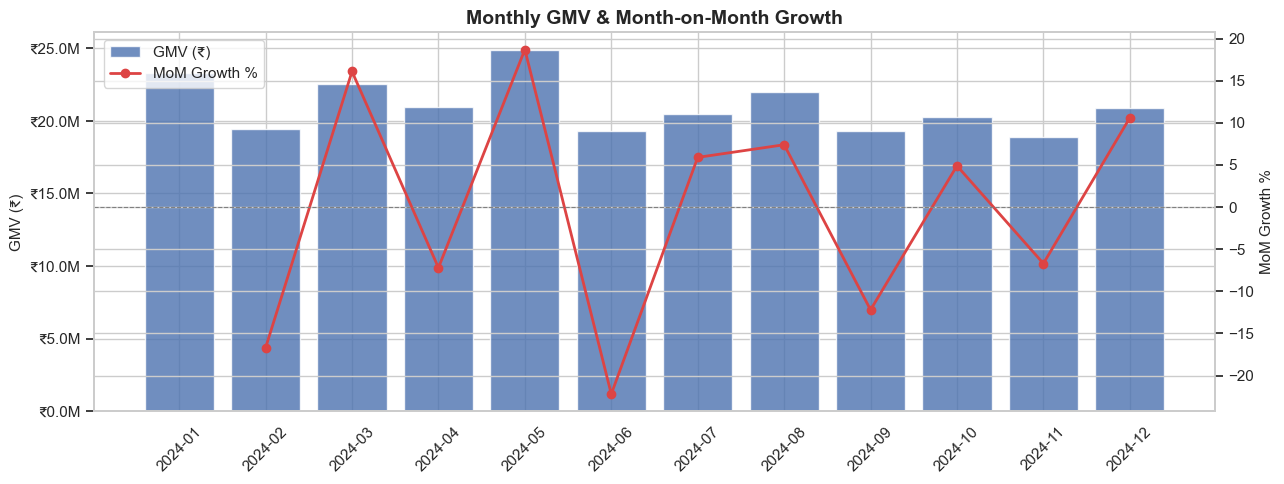

In [44]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(df_monthly["order_month"], df_monthly["total_revenue"],
        color="#4C72B0", alpha=0.8, label="GMV (₹)")
ax1.set_ylabel("GMV (₹)", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e6:.1f}M"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_monthly["order_month"], df_monthly["mom_growth_pct"],
         color="#DD4444", marker="o", linewidth=2, label="MoM Growth %")
ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_ylabel("MoM Growth %", fontsize=11)

ax1.set_title("Monthly GMV & Month-on-Month Growth", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.show()

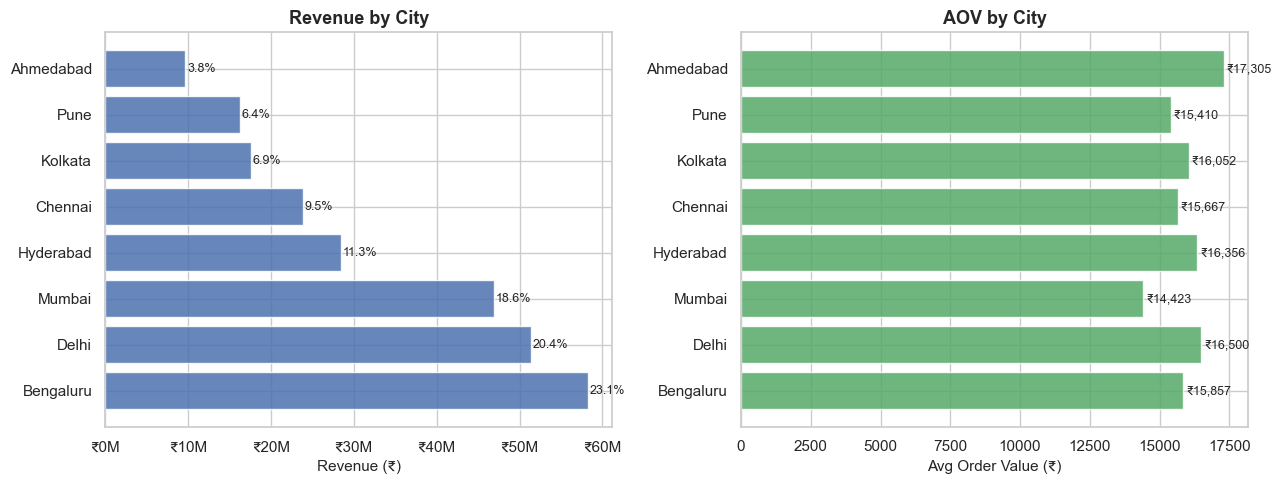

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar — revenue
axes[0].barh(df_city["city"], df_city["revenue_inr"], color="#4C72B0", alpha=0.85)
axes[0].set_xlabel("Revenue (₹)", fontsize=11)
axes[0].set_title("Revenue by City", fontsize=13, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e6:.0f}M"))
for i, (val, share) in enumerate(zip(df_city["revenue_inr"], df_city["revenue_share_pct"])):
    axes[0].text(val + 2e5, i, f"{share}%", va="center", fontsize=9)

# Bar — AOV
axes[1].barh(df_city["city"], df_city["aov_inr"], color="#55A868", alpha=0.85)
axes[1].set_xlabel("Avg Order Value (₹)", fontsize=11)
axes[1].set_title("AOV by City", fontsize=13, fontweight="bold")
for i, val in enumerate(df_city["aov_inr"]):
    axes[1].text(val + 100, i, f"₹{val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

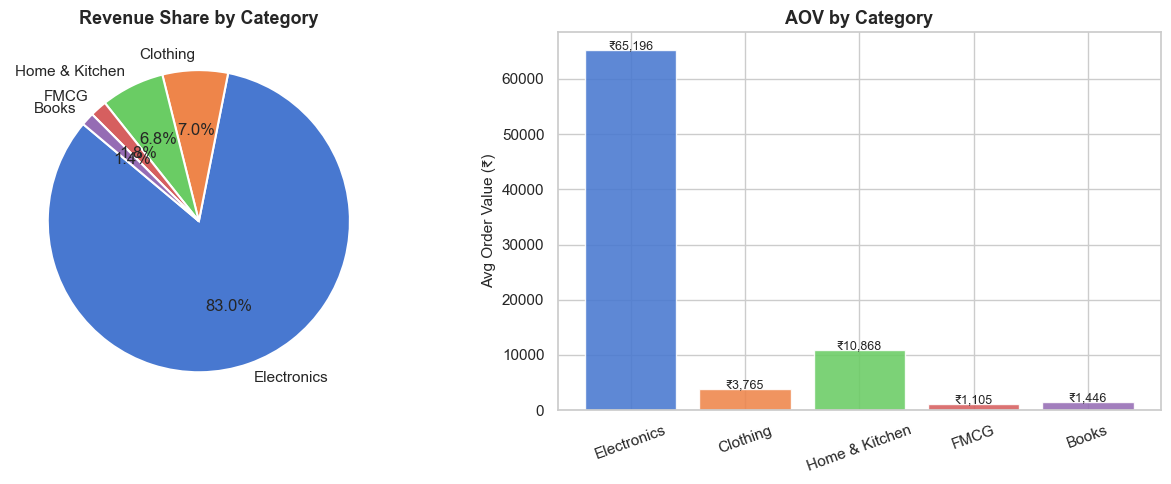

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = sns.color_palette("muted", len(df_category))

# Pie — revenue share
axes[0].pie(df_category["revenue_share_pct"], labels=df_category["category"],
            autopct="%1.1f%%", colors=colors, startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Revenue Share by Category", fontsize=13, fontweight="bold")

# Bar — AOV
axes[1].bar(df_category["category"], df_category["aov_inr"], color=colors, alpha=0.88)
axes[1].set_ylabel("Avg Order Value (₹)", fontsize=11)
axes[1].set_title("AOV by Category", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
for i, val in enumerate(df_category["aov_inr"]):
    axes[1].text(i, val + 200, f"₹{val:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

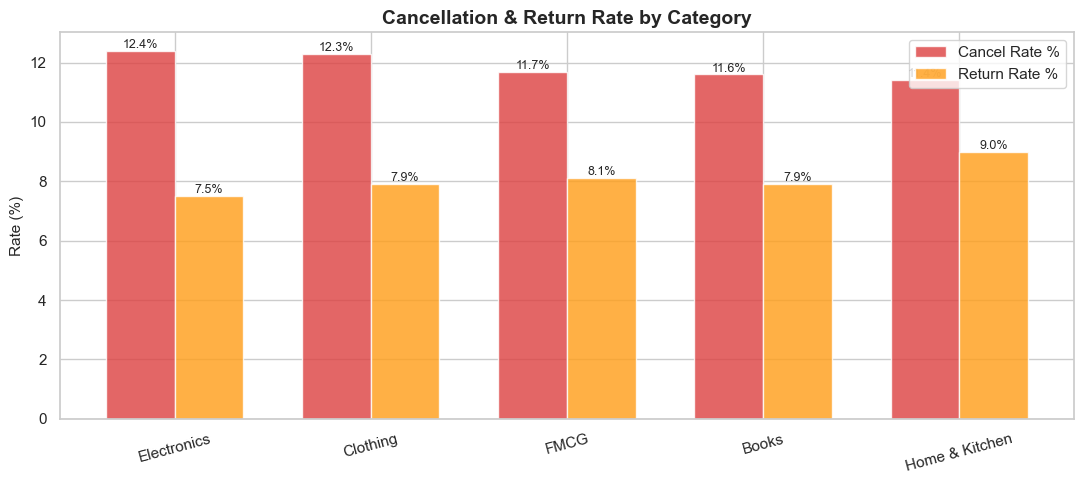

In [47]:
fig, ax = plt.subplots(figsize=(11, 5))

x = range(len(df_returns))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df_returns["cancel_rate_pct"],
               width, label="Cancel Rate %", color="#DD4444", alpha=0.82)
bars2 = ax.bar([i + width/2 for i in x], df_returns["return_rate_pct"],
               width, label="Return Rate %", color="#FF9F1C", alpha=0.82)

ax.set_xticks(list(x))
ax.set_xticklabels(df_returns["category"], rotation=15)
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Cancellation & Return Rate by Category", fontsize=14, fontweight="bold")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height()}%", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height()}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

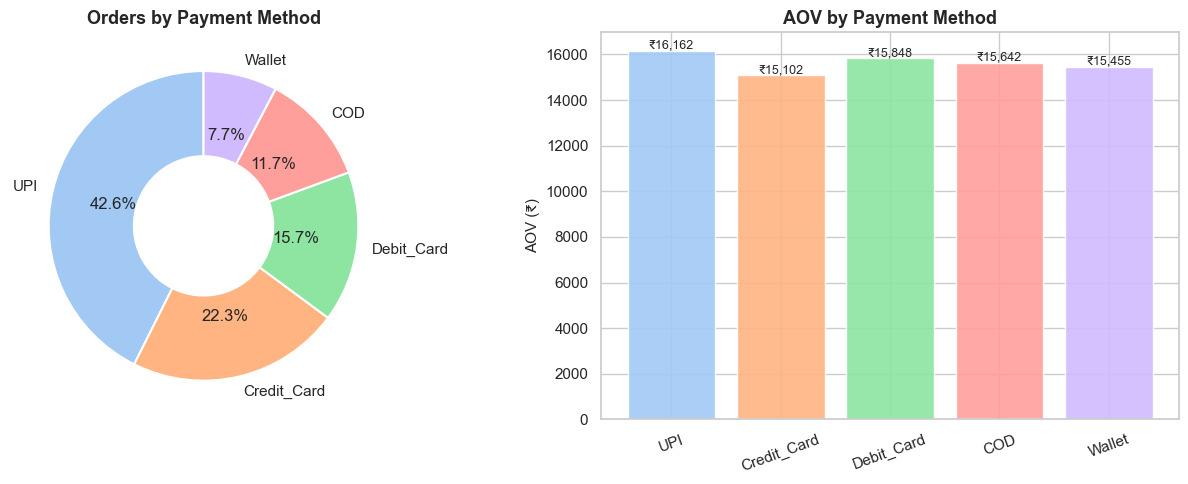

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = sns.color_palette("pastel", len(df_payment))

# Donut
wedges, texts, autotexts = axes[0].pie(
    df_payment["orders"], labels=df_payment["payment_method"],
    autopct="%1.1f%%", colors=colors, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5, "width": 0.55})
axes[0].set_title("Orders by Payment Method", fontsize=13, fontweight="bold")

# AOV comparison
axes[1].bar(df_payment["payment_method"], df_payment["aov_inr"],
            color=colors, alpha=0.9, edgecolor="white")
axes[1].set_ylabel("AOV (₹)", fontsize=11)
axes[1].set_title("AOV by Payment Method", fontsize=13, fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
for i, val in enumerate(df_payment["aov_inr"]):
    axes[1].text(i, val + 100, f"₹{val:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

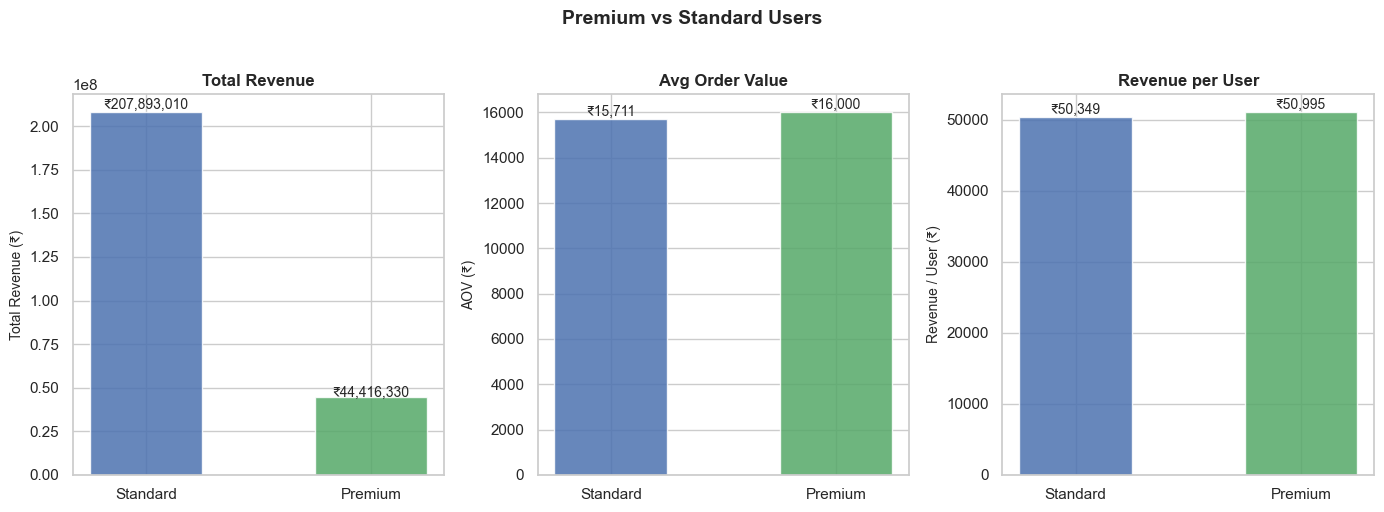

In [49]:
df_premium["label"] = df_premium["is_premium"].map({True: "Premium", False: "Standard"})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#4C72B0", "#55A868"]

metrics = [
    ("total_revenue_inr", "Total Revenue (₹)", "Total Revenue"),
    ("aov_inr",           "AOV (₹)",           "Avg Order Value"),
    ("revenue_per_user_inr", "Revenue / User (₹)", "Revenue per User"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    bars = ax.bar(df_premium["label"], df_premium[col], color=colors, alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=10)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"₹{bar.get_height():,.0f}", ha="center", fontsize=10)

plt.suptitle("Premium vs Standard Users", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()